# Assignment 3: Predicting Mapping Penalties with a From-Scratch ANN

**Author:** Albany Latunij

**Student Number:** 22202053

**Due Date** June 4, 2026, 11:59PM

This assignment requires is to implement a feed-forward artificial neural network (ANN) from scratch which is able predict the penalty score of a mapping between tasks and employees.

This notebook will:
- import the required modules and libraries
- generate and load the 100 mappings dataset
- preprocess the data into 110 dimension vectors
- define the ANN models and implement forward and backward
- train models through mini-batch SGD
- generate eight required figures for comparison
- save and export results
    

## 1. Imports

The imports required for this assignment are done below. The library imports requried include Numpy, Pandas, Pyplot, and Time to be able to incorporate numeric operations, data I/O, data plotting, and timing. The synthetic dataset from the task sheet is utilised in constructing the input vectors. The cost function and mapping evaluation are resused from Assessment Task 1 and are imported from their local project files.

In [ ]:
import os, sys

if not os.path.exists('/content/ANN_Assignment'):
    !git clone https://github.com/Albany-Latunij/ANN_Assignment.git /content/ANN_Assignment

sys.path.append('/content/ANN_Assignment')

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from google.colab import files

from task_data import tasks, employees, calculate_cost_function
from genetic_algorithm import generate_chromosome, evaluate_chromosome_fitness

## 2. Data Generation
In this section we require to generate the 100 mappings. This is done using the functions `generate_chromosome` and `evaluate_chromosome_fitness` from Assessment 1. Using these funcitons, 100 random task-employee combinations are generated and evaluated, each providing a penalty score. Here, each mapping is a chromosome which is an array of 10 employee IDs which represents which employee each task is assigned to.

In [ ]:
num_tasks = len(tasks)
num_employees = len(employees)

rows = []
for i in range(100):
    chromosome = generate_chromosome(num_tasks, num_employees)
    cost, c = evaluate_chromosome_fitness(chromosome)
    row = list(chromosome) + [cost]
    rows.append(row)

columns = [f"T{i+1}" for i in range(num_tasks)] + ["penalty"]
df = pd.DataFrame(rows, columns = columns)
df.to_csv("mappings.csv", index = False)


## 3. Preprocessing and Encoding
Data preprocessing contains two funcitons. The `one_hot_encode_skill` helps to encode the task and employee skillset categorical features into a numeric vector. For example:

Skill 'A' is represented as [1, 0, 0]

Skills {'A', 'C'} is represented as [1, 0, 1]

The function `construct_input_vector` builds a 110 dimensional input vector from a single mapping row. This is done as it include the 6 features of the task, and the 5 features of the employee.

In [ ]:
def one_hot_encode_skill(skills):
    mapping = {'A': 0, 'B': 1, 'C': 2}
    vec = [0, 0, 0]

    for s in skills:
        vec[mapping[s]] = 1
    return vec


def construct_input_vector(mapping_row):
    """
    Construct 110 dimension vector from task-employee assignments + penalty
    """
    input_vector = []

    # loop though each task
    for task_idx in range(10):

        #1-based ID
        task_id = task_idx + 1
        # get which employee the task is assigned to
        emp_id = int(mapping_row[task_idx])

        #look up the task and employee data from task_data.py
        task = tasks[task_id]
        emp = employees[emp_id]

        # build 11 element vector for task-employee pair
        pair_vector = [
            task["estimated_time"], # hours needed
            task["difficulty"], # difficulty level
            task["deadline"],   # deadline
            *one_hot_encode_skill(task["skill"]), # required skills
            emp["available_hours"], # employee capacity
            emp["skill_level"], # employee skill rating
            *one_hot_encode_skill(emp["skills"]), # employee skills
        ]

        #adds each element individually to the main vector
        input_vector.extend(pair_vector)
    return input_vector

Data is loaded from the CSV file and preprocessed so that they are ready to be fed into the neural network. This includes encoding the mapping assignments into the input array and splitting into training, validation, and testiung sets in a 70/15/15 proportion. The input datasets are transposed so that each column represents one sample which is the format the network expects for matrix multiplication.

In [ ]:
# build input matrix and target vector
data_df = pd.read_csv('mappings.csv')
data = data_df.values # (N, 11) 10 assignments + 1 penalty

# split assignments and penalties
assignments, penalties = [], []
for row in data:
    assignments.append(construct_input_vector(row))
    penalties.append(row[-1])

X = np.vstack(assignments)
y = np.array(penalties).reshape(-1, 1)

# split based on training, validation and testing

X_train = X[:70].T
y_train = y[:70].T

X_val = X[70:85].T
y_val = y[70:85].T

X_test = X[85:].T
y_test = y[85:].T


## 4. Model Design
This assignment requires us to implement two different feed-forward architectures.


### Activation Functions
Activation functions are non linear functions which are applied to the data in the hidden layer of the ANN to produce the neuron's output, without this, the network will not be able to learn complex patterns.

#### **Sigmoid**

The sigmoid function is represented by the following formula:
$$\sigma(x) = \frac{1}{1+e^{-x}} $$

where $x$ is the input to the function and the output will always be a value between 0 and 1.

The derivative of the funciton is:
$$\sigma'(x) = \sigma(x)(1=\sigma(x))$$

---
#### **ReLU**
The rectified linear unit (ReLU) is defined as:
$$ReLU(x) = \max(0,x)$$

where $x$ is the input to the function and the output will always be positive, if the input value is negative it will be set to 0.

The derivative of the function is:
$$ReLU'(x) = \begin{cases} 1, & x > 0 \\ 0, & x \le 0 \end{cases}$$

---
#### **Implementation of Activation Functions**

Both sigmoid and ReLU functions compute and return the activation value of $A$ and the cached pre-activation input $Z$ before weights and biases are applied.

Both backward functions *sigmoid_back* and *relu_back* takes in the gradient $dA$ and the cached values to calculate the gradient with respect to $Z$ using their corresponding derivatives.

In [ ]:
def sigmoid(Z):
    # Sigmoid activation function
    A = 1 / (1 + np.exp(-Z))
    cache = Z
    return A, cache

def sigmoid_back(dA, cache):
    # Backward propagation for single sigmoid unit
    Z = cache
    s = 1 / (1 + np.exp(-Z))
    dZ = dA * s * (1 - s)
    return dZ

def relu(Z):
    # ReLU activation function
    A = np.maximum(0,Z)
    cache = Z
    return A, cache

def relu_back(dA, cache):
    # Backward propagation for single ReLU unit
    Z = cache
    dZ = np.array(dA, copy = True)

    dZ[Z <= 0] = 0
    return dZ

## Neural Network Class

#### **Initialise Parameters**

First, the weights and biases are set up. for each layer $l$, the weight matrix $W^{[l]}$ has dimensions $(n^{[l]}, n^{[l-1]})$ and is filled with small random values between 0 and 0.01. $n^{[l]}$ is the neuron count in layer $l$ and $n^{[l-1]}$ is the neuron count in the layer before it. The bias vector $b^{[l]}$ has dimensions $(n{[l]}, 1)$ and is initialised to zeros.

---

#### **Forward Propagation**

The forward pass pushes data through the network layer by layer. At each hidden layer $l$, we compute:

$$Z^{[l]} = W^{[l]} \cdot A^{[l-1]} + b^{[l]}$$

$$A^{[l]} = g(Z^{[l]})$$

Where $A^{[0]} = X$ is the raw input and $g(\cdot)$ is the activation function. At the final output layer, we take the linear output $Z^{[l]}$ directly as the predicted value $Y$.

---

#### **Compute Cost**
To measure how far off the predictions are, we use Mean Squared Error (MSE):

$$L = \frac{1}{N} \sum_{i=1}^{N} (y_{i} - \hat{y}_{i})^{2}$$

where $\hat{y}_{i}$ is the network's predition for the *i*-th example and ${y}_{i}$ is the true output.

---

#### **Backpropagation**
The backward pass works out how much each parameter contributed to the error, using the chain rule. Starting at the output layer, the error signal is:

$$dZ^{[L]} = \frac{2}{N}(\hat{Y} - Y)$$

From there, we compute the gradients for the weights and biases at each layer *l*:

$$dW^{[l]} = \frac{1}{m} dZ^{[l]} \cdot A^{[l-1]T}$$

$$db^{[l]} = \frac{1}{m} \sum dZ^{[l]}$$


---

#### **Updating Parameters**
Once we have the gradients, gradient adescent steps each parameter in the direction that lowers the cost:
$$W^{[l]} = W^{[l]} - \alpha \cdot dW^{[l]}$$

$$b^{[l]} = b^{[l]} - \alpha \cdot db^{[l]}$$

Where $\alpha$ is the learning rate.


In [ ]:
class NeuralNetwork :
    def __init__ (self , layer_dims = [110, 256, 1] , learning_rate = 1e-3, activation = 'relu'):
        # initialise parameters of the neural network
        self.layer_dims = layer_dims
        self.learning_rate = learning_rate

        # pick activation function and its derivative
        if activation.lower() == 'relu':
            self.activation = relu
            self.activation_back = relu_back

        else:
            self.activation = sigmoid
            self.activation_back = sigmoid_back

        # number of layers exluding input
        self.L = len(layer_dims) - 1

        # initialise weights W and biases b for each layer
        self.W = {}
        self.b = {}

        for l in range(1, self.L + 1):
            self.W[l] = np.random.randn(layer_dims[l], layer_dims[l-1]) * 0.01
            self.b[l] = np.zeros((layer_dims[l], 1))

    def forward (self , X):
        # perform a full forward pass
        caches = []
        A = X

        # hidden layers
        for l in range(1, self.L):
            Z = self.W[l] @ A + self.b[l]
            caches.append(((A, self.W[l], self.b[l]), Z))
            A, cache = self.activation(Z)

        # output layer
        Z = self.W[self.L] @ A + self.b[self.L]
        caches.append(((A, self.W[self.L], self.b[self.L]), Z))

        return Z, caches

    def back_layer(self, dZ, cache):
        # backprop for a single layer dZ = dL/dZ_l
        (A_prev , W, b), Z = cache
        m = A_prev.shape[1]
        dW = (1/m) * (dZ @ A_prev.T)
        db = (1/m) * np.sum(dZ, axis = 1, keepdims = True)
        dA_prev = W.T @ dZ

        return dA_prev, dW, db


    def backward (self , Y_hat, Y, caches):
        # back propagation over the network
        # returns dict of grads → {dW1, db1, ..., dWL, dbL}
        grads = {}
        m = Y.shape[1]

        # output layer
        # dZ is MSE loss
        dZ = 2 * (Y_hat - Y) / m
        dA_prev, dW, db = self.back_layer(dZ, caches[-1])

        # gradients (layer L)
        grads[f'dW{self.L}'] = dW
        grads[f'db{self.L}'] = db

        # hidden layers

        dA = dA_prev

        for l in reversed(range(1, self.L)):
            cache_l = caches[l-1]
            Z = cache_l[1]
            dZ = self.activation_back(dA, Z)
            dA, dW, db = self.back_layer(dZ, cache_l)
            grads[f'dW{l}'] = dW
            grads[f'db{l}'] = db

        return grads

    def update_params (self , grads):
        # apply gradient descent
        for l in range(1, self.L + 1):
            self.W[l] -= self.learning_rate * grads[f'dW{l}']
            self.b[l] -= self.learning_rate * grads[f'db{l}']

    def compute_cost(self, Y_true, Y_hat):
        # mean squared error
        return float(np.mean((Y_true - Y_hat) ** 2))

## 5. Training Loop and Hyperparameter Grid Search

This section run a grid search over the key hyperparameters:

* Learning rate (0.01, 0.001, 0.0001)

* Batch size (6, 16, 32)

* Activation function (Sigmoid & ReLU)

using each of the two network models. A new model is created for ever combination and trained using mini-batch gradient descent (shuffling the training set each epoch and recording both training and validation losses plus epoch timing), and then evaluate its performance on the remaining test set. All results and hyperparameter settings are stored in a list of dictionaries which is used to identify and report the combination that achieves the lowest test loss for each model.

In [ ]:
def grid_search_training(layer_dims):
    # perform model training over a grid of hyperparameters

    #hyperparameter grid
    learning_rates = [0.01, 0.001, 0.0001]
    batch_sizes = [8, 16, 32]
    activations = ['sigmoid', 'relu']
    epochs = [100, 150, 200]

    results = []

    for lr in learning_rates:
        for bs in batch_sizes:
            for act in activations:
                for num_epochs in epochs:
                    # new model for each combination of parameters
                    np.random.seed(28)
                    model = NeuralNetwork(layer_dims, learning_rate=lr, activation=act)
                    train_losses = []
                    val_losses = []
                    epoch_times = []

                    # loop over epochs
                    for epoch in range(num_epochs):
                        t0 = time.time()

                        # shuffle training set
                        perm = np.random.permutation(X_train.shape[1])
                        X_sh, y_sh = X_train[:, perm], y_train[:, perm]

                        # mini batch SGD
                        for i in range(0, X_sh.shape[1], bs):
                            xb = X_sh[:, i:i+bs]
                            yb = y_sh[:, i:i+bs]

                            # forward → backward → update
                            y_hat, caches = model.forward(xb)
                            grads = model.backward(y_hat, yb, caches)
                            model.update_params(grads)

                        # record losses and timing
                        y_hat_tr, caches = model.forward(X_train)
                        train_losses.append(model.compute_cost(y_train, y_hat_tr))

                        y_hat_val, caches = model.forward(X_val)
                        val_losses.append(model.compute_cost(y_val, y_hat_val))

                        epoch_times.append(time.time() - t0)

                    # final test evaluation
                    y_hat_test, caches = model.forward(X_test)
                    test_loss = model.compute_cost(y_test, y_hat_test)

                    results.append({
                            'layer_dims': layer_dims,
                            'learning_rate': lr,
                            'batch_size': bs,
                            'activation': act,
                            'num_epochs': num_epochs,
                            'train_losses': train_losses,
                            'val_losses': val_losses,
                            'epoch_times': epoch_times,
                            'test_loss': test_loss
                    })

                    print(f'lr={lr}, bs={bs}, act={act}, epochs={num_epochs}: '
                            f'train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}, test={test_loss:.4f}')

    return results

#define model architectures
modelA = [110, 256, 1]
modelB = [110, 128, 128, 1]

# run training grid and search
resultsA = grid_search_training(modelA)
resultsB = grid_search_training(modelB)

# find the run with minimum test loss
bestA = min(resultsA, key=lambda r: r['test_loss'])
bestB = min(resultsB, key=lambda r: r['test_loss'])

print(f"Model A best test loss: {bestA['test_loss']:.4f} "
      f"(epochs={bestA['num_epochs']}, lr={bestA['learning_rate']}, "
      f"bs={bestA['batch_size']}, act={bestA['activation']})")

print(f"Model B best test loss: {bestB['test_loss']:.4f} "
      f"(epochs={bestB['num_epochs']}, lr={bestB['learning_rate']}, "
      f"bs={bestB['batch_size']}, act={bestB['activation']})")


lr=0.01, bs=8, act=sigmoid, epochs=100: train=4.1888, val=3.6672, test=7.1175
lr=0.01, bs=8, act=sigmoid, epochs=150: train=4.2707, val=4.6764, test=8.7125
lr=0.01, bs=8, act=sigmoid, epochs=200: train=3.7034, val=4.1872, test=8.5047
lr=0.01, bs=8, act=relu, epochs=100: train=5.6565, val=6.8066, test=11.8713
lr=0.01, bs=8, act=relu, epochs=150: train=3.5987, val=3.9688, test=8.6451
lr=0.01, bs=8, act=relu, epochs=200: train=4.9493, val=5.0184, test=8.9210
lr=0.01, bs=16, act=sigmoid, epochs=100: train=5.4226, val=3.1815, test=6.0127
lr=0.01, bs=16, act=sigmoid, epochs=150: train=5.0805, val=4.2901, test=7.5275
lr=0.01, bs=16, act=sigmoid, epochs=200: train=4.5486, val=3.4467, test=6.5256
lr=0.01, bs=16, act=relu, epochs=100: train=13.2903, val=15.4372, test=20.3850
lr=0.01, bs=16, act=relu, epochs=150: train=4.5970, val=5.3359, test=9.8195
lr=0.01, bs=16, act=relu, epochs=200: train=4.9483, val=4.5342, test=8.3462
lr=0.01, bs=32, act=sigmoid, epochs=100: train=5.5321, val=4.3629, test=

## 6. Evaluation and Plots

### Epoch vs Loss (Train & Val)
A helper function that pulls the training and validation loss curves for a given learning rate, batch size and activation from the grid search results, then plots them over epochs for each model, showing how training and validation MSE evolve over 100 epochs.

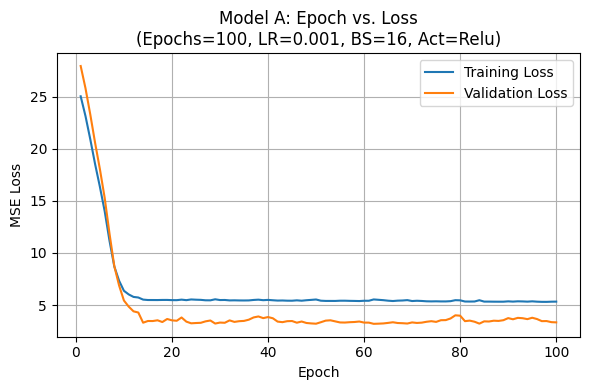

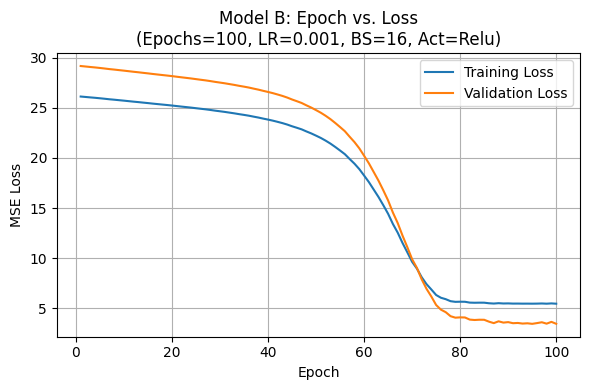

In [ ]:
def plot_epoch_vs_loss(runs, model_label, learning_rate=0.001, batch_size=16, activation='relu', num_epochs=100, out_file=None):
    # plot epoch vs training and validation loss
    run = next(r for r in runs
               if r['learning_rate'] == learning_rate
               and r['batch_size'] == batch_size
               and r['activation'] == activation
               and r['num_epochs'] == num_epochs)

    train, val = run['train_losses'], run['val_losses']
    epochs = range(1, len(train) + 1)

    plt.figure(figsize=(6,4))
    plt.plot(epochs, train, label='Training Loss')
    plt.plot(epochs, val,   label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(
        f"{model_label}: Epoch vs. Loss\n"
        f"(Epochs={num_epochs}, LR={learning_rate}, "
        f"BS={batch_size}, Act={activation.capitalize()})"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file)
    plt.show()

plot_epoch_vs_loss(resultsA, 'Model A', out_file='modelA_Epoch_vs_Loss.png')
plot_epoch_vs_loss(resultsB, 'Model B', out_file='modelB_Epoch_vs_Loss.png')



### Learning Rate vs Loss (Test)

helper function that scans the grid search results for a fixed batch size and activation, collects and sorts each run's pair of learning rate and test loss, and then plots test loss against learning rate on a log scale. The function is called once for each model and then generates and saves the corresponding LR vs test loss curves.

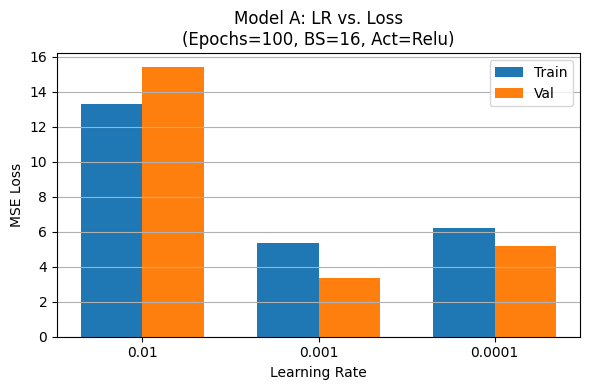

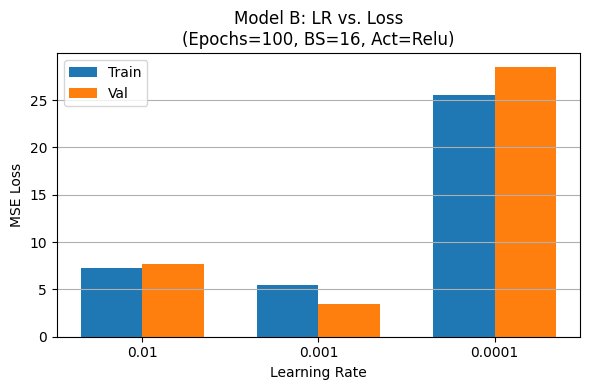

In [ ]:
def plot_lr_vs_loss(runs, model_label, batch_size=16, activation='relu', num_epochs=100, out_file=None):
    # Helper function for plotting learning rate vs MSE train & val loss

    lrs = [0.01, 0.001, 0.0001]
    train_losses = []
    val_losses = []
    for lr in lrs:
        run = next(r for r in runs
                   if r['learning_rate'] == lr
                   and r['batch_size'] == batch_size
                   and r['activation'] == activation
                   and r['num_epochs'] == num_epochs)
        train_losses.append(run['train_losses'][-1])
        val_losses.append(run['val_losses'][-1])

    x = np.arange(len(lrs))
    width = 0.35

    plt.figure(figsize=(6, 4))
    plt.bar(x - width/2, train_losses, width, label='Train')
    plt.bar(x + width/2, val_losses,   width, label='Val')
    plt.xticks(x, ['0.01', '0.001', '0.0001'])
    plt.xlabel('Learning Rate')
    plt.ylabel('MSE Loss')
    plt.title(
        f"{model_label}: LR vs. Loss\n"
        f"(Epochs={num_epochs}, BS={batch_size}, Act={activation.capitalize()})"
    )
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file)
    plt.show()

plot_lr_vs_loss(resultsA, 'Model A', out_file='modelA_LR_vs_Loss.png')
plot_lr_vs_loss(resultsB, 'Model B', out_file='modelB_LR_vs_Loss.png')

### Activation Function vs Loss (Train & Val)
This function pulls out the run's final epoch training and validation losses for each activation function and displays them to allow for comparison of how each function perfomed.

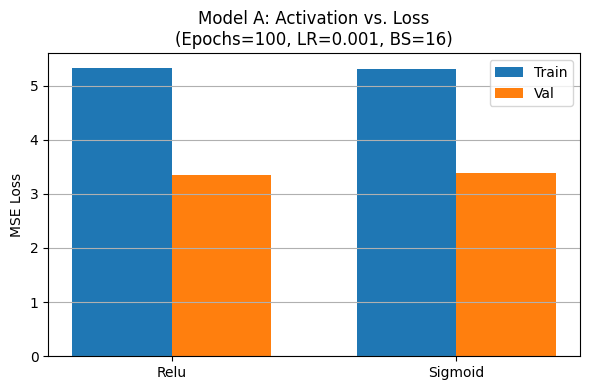

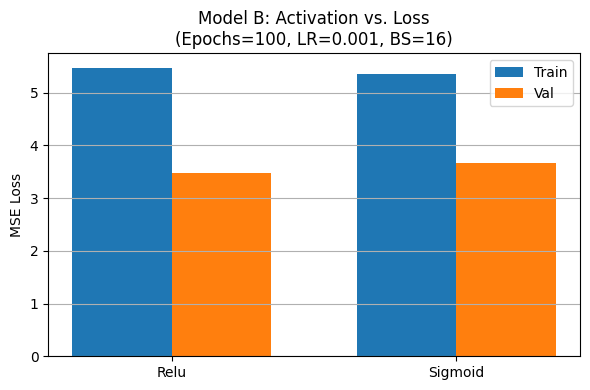

In [ ]:
def plot_activation_vs_loss(runs, model_label, learning_rate=0.001, batch_size=16,
                            activations=('relu', 'sigmoid'), num_epochs=100,
                            out_file=None):

    # helper function for plotting activation function vs MSE loss

    # Collect last-epoch train & val losses for each activation
    train_losses = []
    val_losses   = []
    for act in activations:
        run = next(r for r in runs
                   if r['activation'] == act
                   and r['learning_rate'] == learning_rate
                   and r['batch_size'] == batch_size
                   and r['num_epochs'] == num_epochs)
        train_losses.append(run['train_losses'][-1])
        val_losses.append(  run['val_losses'][-1])

    x = np.arange(len(activations))
    width = 0.35

    plt.figure(figsize=(6, 4))
    plt.bar(x - width/2, train_losses, width, label='Train')
    plt.bar(x + width/2, val_losses,   width, label='Val')
    plt.xticks(x, [a.capitalize() for a in activations])
    plt.title(
        f"{model_label}: Activation vs. Loss\n"
        f"(Epochs={num_epochs}, LR={learning_rate}, BS={batch_size})"
    )
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, dpi=150)
    plt.show()

plot_activation_vs_loss(resultsA, 'Model A', out_file='modelA_AF_vs_Loss.png')
plot_activation_vs_loss(resultsB, 'Model B', out_file='modelB_AF_vs_Loss.png')




### Batch Size vs Epoch Time

For a fixed learning rate and activation, this function grabs each run's average epoch timing across batch sizes (8, 16, 32) from the grid search results and plots them as a bar chart which show how increasing the batch size impacts training speed.

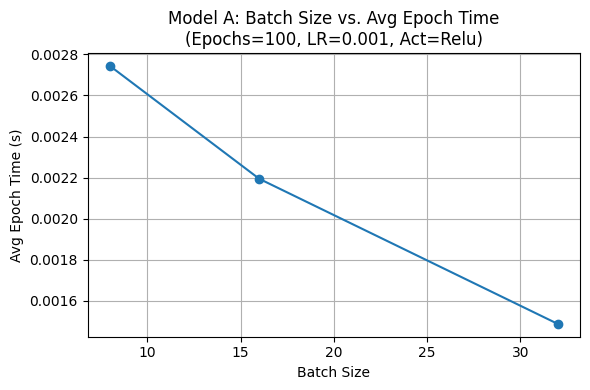

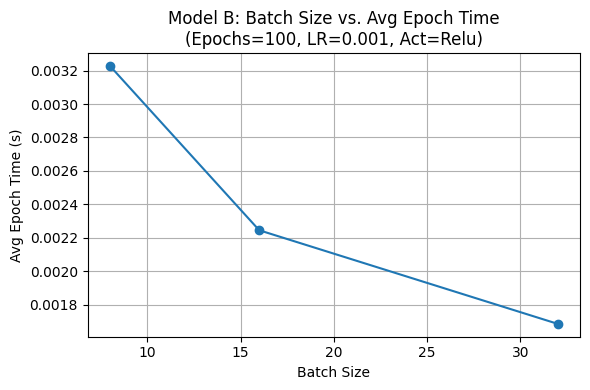

In [ ]:
def plot_bs_vs_epoch_time(runs, model_label, learning_rate=0.001, activation='relu',
                          batch_sizes=(8, 16, 32), num_epochs=100, out_file=None):

    # Helper function for plotting batch size vs. avg epoch time

    avg_times = []
    for bs in batch_sizes:
        run = next(r for r in runs
                   if r['batch_size'] == bs
                   and r['learning_rate'] == learning_rate
                   and r['activation'] == activation
                   and r['num_epochs'] == num_epochs)
        avg_times.append(np.mean(run['epoch_times']))

    plt.figure(figsize=(6,4))
    plt.plot(batch_sizes, avg_times, marker='o')
    plt.xlabel('Batch Size')
    plt.ylabel('Avg Epoch Time (s)')
    plt.title(
        f"{model_label}: Batch Size vs. Avg Epoch Time\n"
        f"(Epochs={num_epochs}, LR={learning_rate}, Act={activation.capitalize()})"
    )
    plt.grid(True)
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file)
    plt.show()

plot_bs_vs_epoch_time(runs=resultsA, model_label='Model A', out_file='modelA_BS_vs_EpochTime.png')
plot_bs_vs_epoch_time(runs=resultsB, model_label='Model B', out_file='modelB_BS_vs_EpochTime.png')

## 7. Save & Export
Run to save every plot locally

In [ ]:
download = input("Download all figures? (y/n): ").strip().lower()
if download in ('y', 'yes'):
    files.download('modelA_Epoch_vs_Loss.png')
    files.download('modelB_Epoch_vs_Loss.png')
    files.download('modelA_LR_vs_Loss.png')
    files.download('modelB_LR_vs_Loss.png')
    files.download('modelA_AF_vs_Loss.png')
    files.download('modelB_AF_vs_Loss.png')
    files.download('modelA_BS_vs_EpochTime.png')
    files.download('modelB_BS_vs_EpochTime.png')
else:
    print("Not Downloading.")
